<a href="https://colab.research.google.com/github/Obi-chidinma2003/100-days-of-data-repository/blob/main/Day_14_Data__Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**IMPORT NECCESSARY LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


**READ DATASET**

In [5]:
path=("/content/drive/MyDrive/Dataset/dairy_dataset.csv")
df=pd.read_csv(path)
df.head()

,Location,Total Land Area (Acres),Number Of Cows,Farm Size,Date,Product Id,Product Name,Brand,Quantity (Liters/Kg),Price Per Unit,...,Production Date,Expiration Date,Quantity Sold (Liters/Kg),Price Per Unit (Sold),Approx. Total Revenue(Inr),Customer Location,Sales Channel,Quantity In Stock (Liters/Kg),Minimum Stock Threshold (Liters/Kg),Reorder Quantity (Liters/Kg)
0,Telangana,310.84,96,Medium,"44,609.00",5,Ice Cream,Dodla Dairy,222.40,85.72,...,44557,44582,7,82.24,575.68,Madhya Pradesh,Wholesale,215,19.55,64.03
1,Uttar Pradesh,19.19,44,Large,44531,1,Milk,Amul,687.48,42.61,...,44472,44494,558,39.24,21895.92,Kerala,Wholesale,129,43.17,181.10
2,Tamil Nadu,581.69,24,Medium,44620,4,Yogurt,Dodla Dairy,503.48,36.50,...,44575,44605,256,33.81,8655.36,Madhya Pradesh,Online,247,15.10,140.83
3,Telangana,908.00,89,Small,43625,3,Cheese,Britannia Industries,823.36,26.52,...,43600,43672,601,28.92,17380.92,Rajasthan,Online,222,74.50,57.68
4,Maharashtra,861.95,21,Medium,44179,8,Buttermilk,Mother Dairy,147.77,83.85,...,44121,44132,145,83.07,12045.15,Jharkhand,Retail,2,76.02,33.40


In [6]:
df.tail()

,Location,Total Land Area (Acres),Number Of Cows,Farm Size,Date,Product Id,Product Name,Brand,Quantity (Liters/Kg),Price Per Unit,...,Production Date,Expiration Date,Quantity Sold (Liters/Kg),Price Per Unit (Sold),Approx. Total Revenue(Inr),Customer Location,Sales Channel,Quantity In Stock (Liters/Kg),Minimum Stock Threshold (Liters/Kg),Reorder Quantity (Liters/Kg)
4320,Delhi,748.71,89,Medium,44616,6,Curd,Mother Dairy,554.90,88.45,...,44608,44613,352,87.20,30694.40,Uttar Pradesh,Online,202,98.07,33.53
4321,Jharkhand,385.91,29,Large,44695,4,Yogurt,Palle2Patnam,818.33,55.35,...,44642,44665,68,58.39,3970.52,Kerala,Retail,750,87.41,114.37
4322,Chandigarh,311.54,65,Small,43835,6,Curd,Mother Dairy,583.56,92.61,...,43834,43841,141,89.46,12613.86,Haryana,Retail,442,33.47,153.66
4323,Maharashtra,890.55,90,Small,44859,6,Curd,Raj,3.10,15.30,...,44836,44843,2,10.56,21.12,Jharkhand,Wholesale,1,58.25,160.84
4324,Rajasthan,492.86,58,Large,43485,1,Milk,Mother Dairy,820.50,49.31,...,43471,43472,417,44.55,18577.35,Madhya Pradesh,Online,403,22.34,189.63


**DESCRIBING THE DATASET BASED ON CERTAIN METRICS**

**CHECKING HOW CLEAN THE DATASET IS**

In [10]:
#shape
df.shape

(4325, 23)

*This simply shows that it has 4325 rows and 23 columns*

In [13]:
#info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4325 entries, 0 to 4324
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Location                             4325 non-null   object 
 1   Total Land Area (Acres)              4325 non-null   float64
 2   Number Of Cows                       4325 non-null   int64  
 3   Farm Size                            4325 non-null   object 
 4   Date                                 4325 non-null   object 
 5   Product Id                           4325 non-null   int64  
 6   Product Name                         4325 non-null   object 
 7   Brand                                4325 non-null   object 
 8   Quantity (Liters/Kg)                 4325 non-null   float64
 9   Price Per Unit                       4325 non-null   float64
 10  Total Value                          4325 non-null   float64
 11  Shelf Life (Days)             

In [22]:
df.isnull().sum()

,0
Location,0
Total Land Area (Acres),0
Number Of Cows,0
Farm Size,0
Date,0
Product Id,0
Product Name,0
Brand,0
Quantity (Liters/Kg),0
Price Per Unit,0


In [23]:
#finding duplicates
df.duplicated().sum()

np.int64(0)

In [27]:
#identifying garbage values
for i in df.select_dtypes(include="object").columns:
 print (df[i].value_counts())
 print()

Location
Delhi             525
Chandigarh        519
Uttar Pradesh     276
Gujarat           267
Karnataka         261
Madhya Pradesh    259
Rajasthan         256
Maharashtra       255
Haryana           253
Kerala            249
Telangana         248
Jharkhand         248
Bihar             245
West Bengal       241
Tamil Nadu        223
Name: count, dtype: int64

Farm Size
Large     1462
Medium    1439
Small     1424
Name: count, dtype: int64

Date
44224        11
44826        10
43941         9
44460         9
44888         9
             ..
44,609.00     1
44513         1
43727         1
43975         1
44239         1
Name: count, Length: 1279, dtype: int64

Product Name
Curd          479
Lassi         447
Paneer        441
Yogurt        437
Buttermilk    435
Butter        431
Milk          429
Ice Cream     423
Ghee          402
Cheese        401
Name: count, dtype: int64

Brand
Amul                    1053
Mother Dairy            1010
Raj                      685
Sudha            

**EXPLORATORY DATA ANALYSIS(EDA)**

In [30]:
#Descriptive statistics
df.describe()

,Total Land Area (Acres),Number Of Cows,Product Id,Quantity (Liters/Kg),Price Per Unit,Total Value,Shelf Life (Days),Production Date,Expiration Date,Quantity Sold (Liters/Kg),Price Per Unit (Sold),Approx. Total Revenue(Inr),Quantity In Stock (Liters/Kg),Minimum Stock Threshold (Liters/Kg),Reorder Quantity (Liters/Kg)
count,4325.000000,4325.000000,4325.000000,4325.000000,4325.000000,4325.000000,4325.000000,4325.000000,4325.000000,4325.000000,4325.00000,4325.000000,4325.000000,4325.000000,4325.000000
mean,503.483073,54.963699,5.509595,500.652657,54.785938,27357.845411,29.127630,44150.370405,44179.498035,248.095029,54.77914,13580.265401,252.068671,55.826143,109.107820
std,285.935061,26.111487,2.842979,288.975915,26.002815,21621.051594,30.272114,420.265444,421.258646,217.024182,26.19279,14617.009122,223.620870,26.301450,51.501035
min,10.170000,10.000000,1.000000,1.170000,10.030000,42.516500,1.000000,43406.000000,43418.000000,1.000000,5.21000,12.540000,0.000000,10.020000,20.020000
25%,252.950000,32.000000,3.000000,254.170000,32.460000,9946.814500,10.000000,43792.000000,43819.000000,69.000000,32.64000,2916.650000,66.000000,32.910000,64.280000
50%,509.170000,55.000000,6.000000,497.550000,54.400000,21869.652900,22.000000,44133.000000,44164.000000,189.000000,54.14000,8394.540000,191.000000,56.460000,108.340000
75%,751.250000,77.000000,8.000000,749.780000,77.460000,40954.441000,30.000000,44516.000000,44543.000000,374.000000,77.46000,19504.550000,387.000000,79.010000,153.390000
max,999.530000,100.000000,10.000000,999.930000,99.990000,99036.369600,150.000000,44917.000000,45063.000000,960.000000,104.51000,89108.900000,976.000000,99.990000,199.950000


In [31]:
df.describe(include="object")

,Location,Farm Size,Date,Product Name,Brand,Storage Condition,Customer Location,Sales Channel
count,4325,4325,4325,4325,4325,4325,4325,4325
unique,15,3,1279,10,11,5,15,3
top,Delhi,Large,44224,Curd,Amul,Refrigerated,Delhi,Retail
freq,525,1462,11,479,1053,2459,499,1478


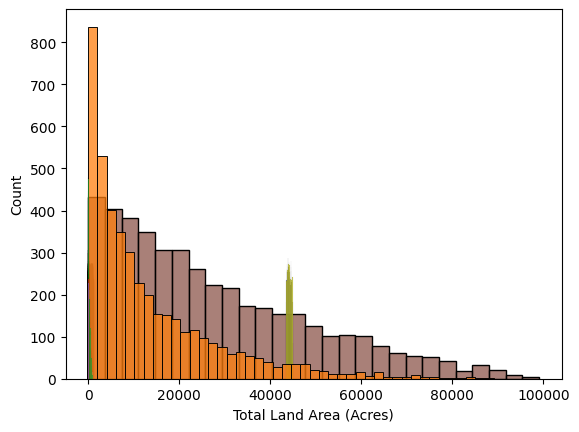

In [45]:
#histogram to understand the distribution
import warnings
warnings.filterwarnings("ignore")
for i in df.select_dtypes(include="number").columns:
 sns.histplot(data=df,x=i)
plt.show()

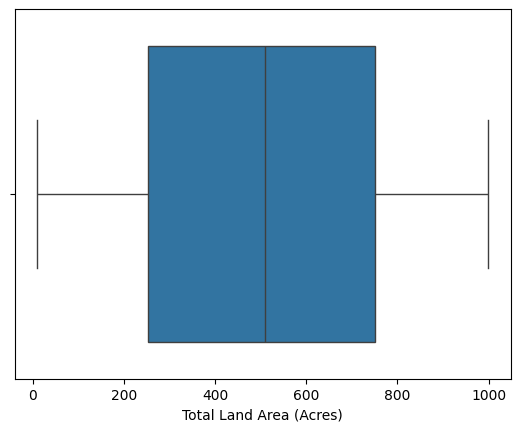

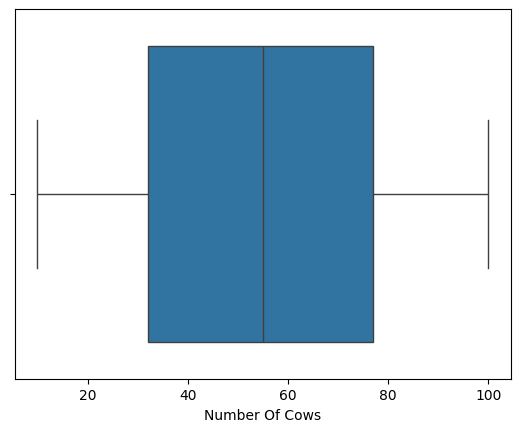

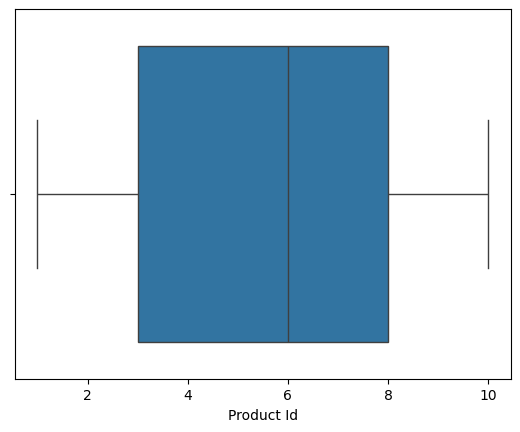

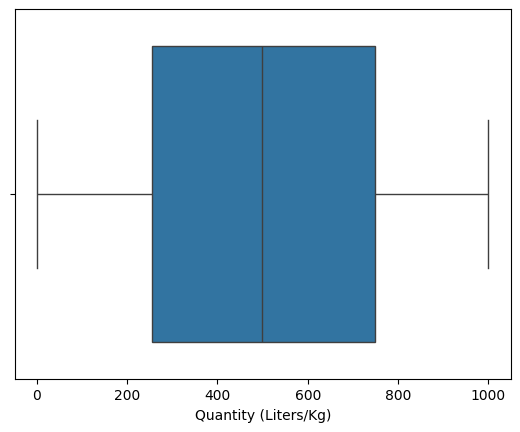

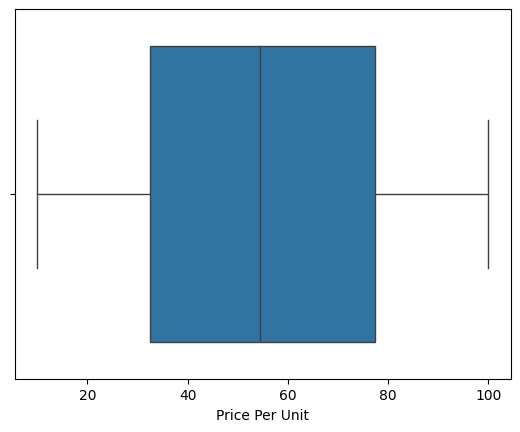

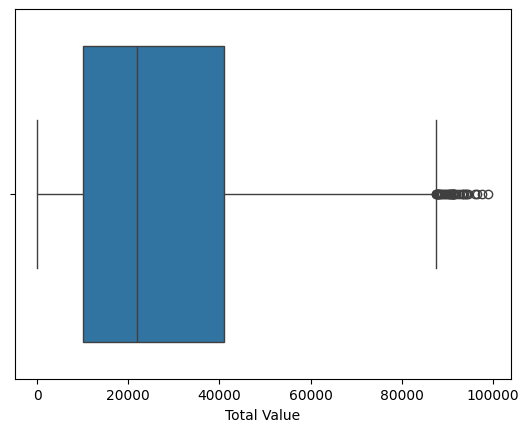

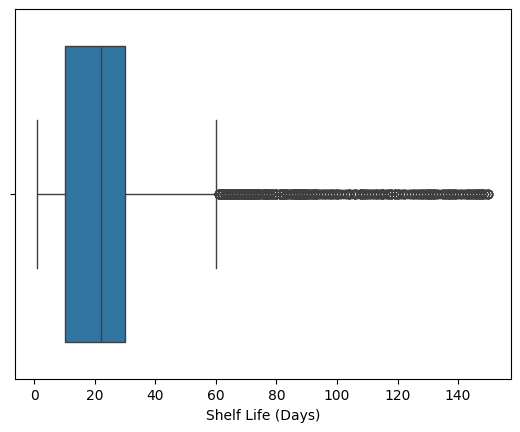

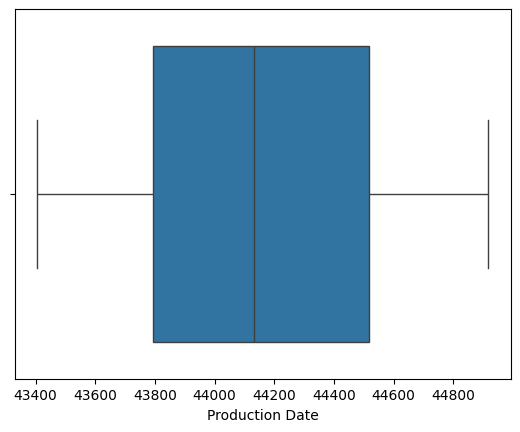

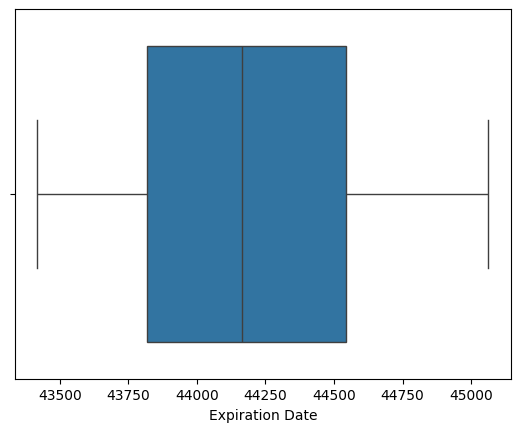

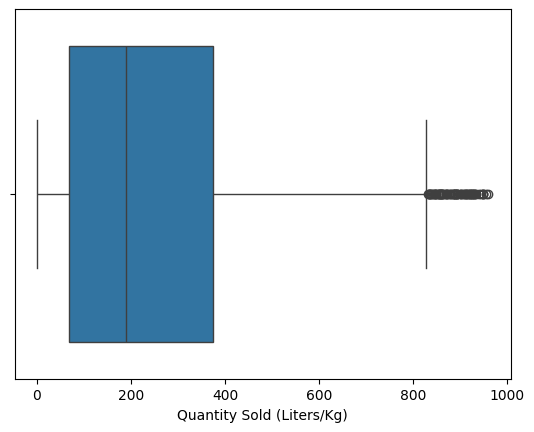

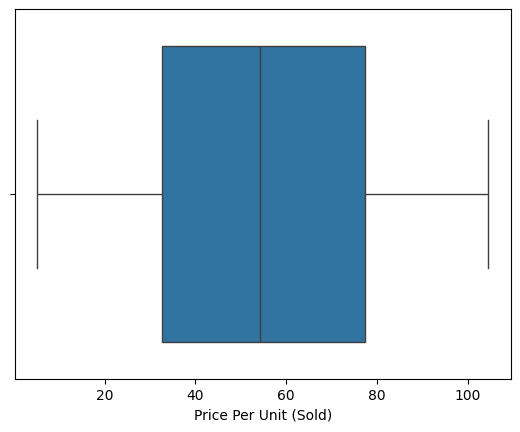

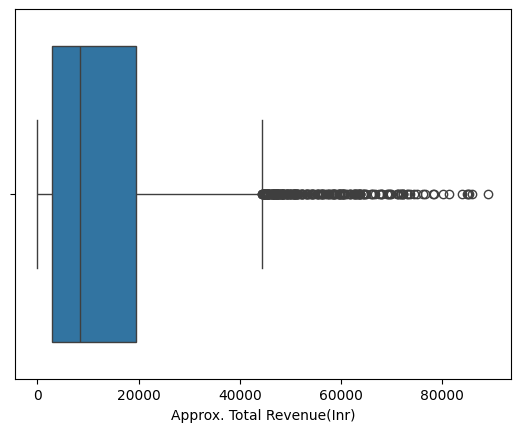

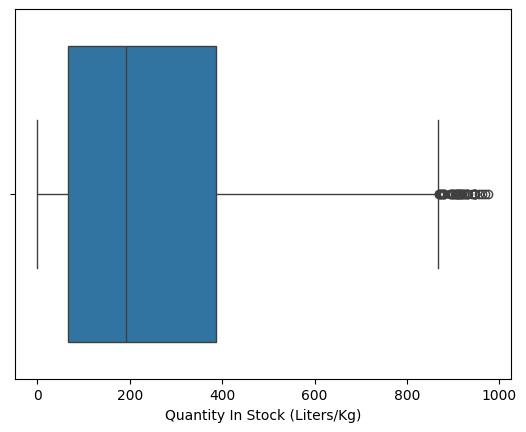

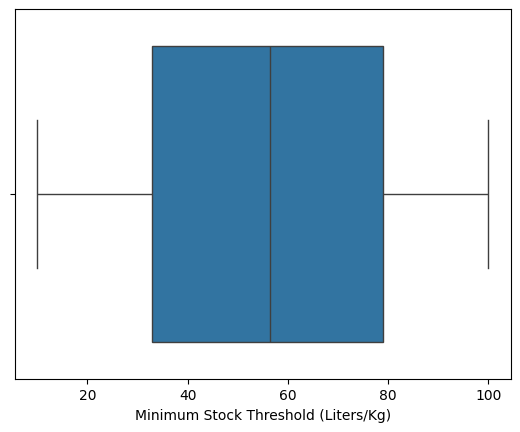

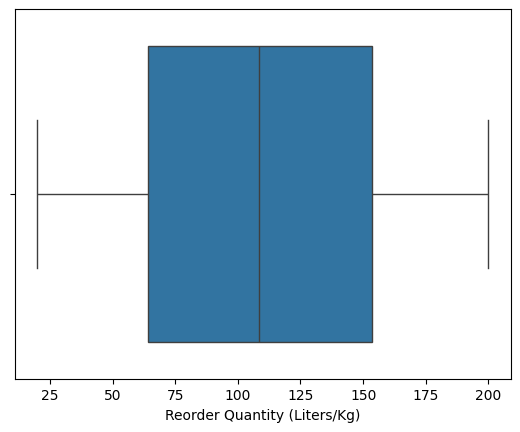

In [46]:
import warnings
warnings.filterwarnings("ignore")
for i in df.select_dtypes(include="number").columns:
 sns.boxplot(data=df,x=i)
 plt.show()

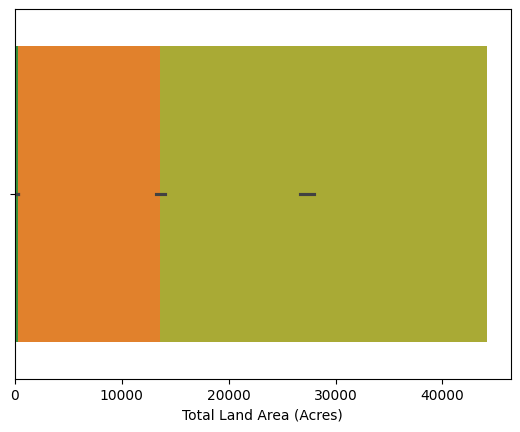

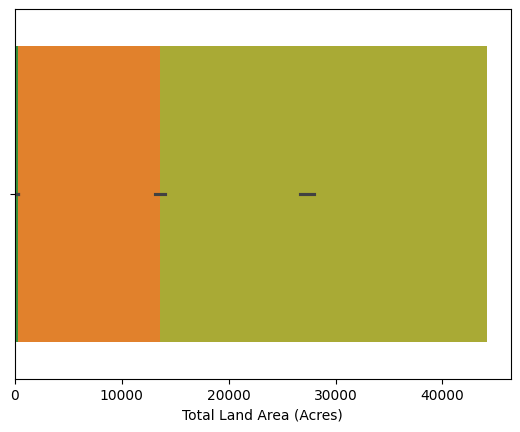

In [48]:
import warnings
warnings.filterwarnings("ignore")
for i in df.select_dtypes(include="number").columns:
 sns.barplot(data=df,x=i)
plt.show()